## Cluster-Mass based Permutation testing in Julia

- Step 1: load and check adjacency matrix
- Step 2: generate simuated data
- Step 3: run cluster-mass permutation test

### Load Libraries

In [3]:
import Pkg
#Pkg.activate("/data/p_02865/tools/UnfoldStats.jl/docs")
Pkg.activate("..")
Pkg.instantiate()


using UnfoldSim
using MAT
using CairoMakie
using Random
using Statistics
using UnfoldMixedModels
using UnfoldStats
using DataFrames
using MixedModelsPermutations
using UnfoldMakie
using Logging
using ClusterDepth
using CSV

ext = Base.get_extension(UnfoldStats, :UnfoldStatsMixedModelsPermutationsExt)
lmm_permutations = ext.lmm_permutations
get_lmm_statistic = ext.get_lmm_statistic


include("../read_adjacency.jl")
include("../cluster_mass_test.jl")


  Activating project at `~/Desktop/ClusterComputation`


spatiotemporal_cluster_pvalues (generic function with 1 method)

In [4]:
# 1. Positions CSV
positions_df = CSV.read("channel_positions_Magda.csv", DataFrame;
                     types=[String, Float64, Float64])

# 2.adjacency CSV
adj_df = CSV.read("adjacency_Magda.csv", DataFrame; stringtype=String, strict=false)

Row,Column1,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,F7,F8,T7,T8,P7,P8,Fz,Cz,Pz,Oz,FC1,FC2,CP1,CP2,FC5,FC6,CP5,CP6,F1,F2,C1,C2,AF3,AF4,FC3,FC4,CP3,CP4,PO3,PO4,F5,F6,C5,C6,P5,P6,AF7,AF8,FT7,FT8,TP7,TP8,PO7,PO8,Fpz,AFz,FCz,CPz,POz
,String,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64
1,Fp1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0
2,Fp2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0
3,F3,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,F4,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,C3,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,C4,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,P3,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,P4,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
9,O1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1


## Correctly format the EEG data
- **60 subjects** (20 per group)
- **3 time points**
- **3 dependent variables** 1/f, alpha and beta (should all be in seperate data arrays)

In [40]:
# remove time dimension
data_1t = data_e[:,8:8,:]

32×1×450 Array{Float64, 3}:
[:, :, 1] =
 -0.004785653463569184
 -1.3732678327922225
 -0.1411172177494422
  0.06533312670959746
  0.5413414768932446
  1.8622516439791656
  1.30675488034463
 -0.3171903699593519
 -0.19212714474928722
  1.6077100081330986
  ⋮
  0.8396239902988647
  0.915451248042992
  0.5784784275121052
 -0.3978056132649824
 -0.219179146404134
 -0.9569227628552724
 -0.4401087931746987
 -0.2755189001675673
 -0.09776862206919637

[:, :, 2] =
  1.7862472960393294
  1.1549796868704698
  2.5932421789057267
  1.3238259676501685
  1.3423481260730379
  1.2450882838241526
  2.681974110009892
  2.2265166747110574
  2.2712717046752555
  5.263428690739923
  ⋮
 -0.6755891090782686
 -1.244027606458618
  0.47792804912701004
 -0.09858475758826783
  0.5863086601629642
  0.27296552029712634
  0.8269558543453028
  0.9011399025588585
  1.1207371966582418

[:, :, 3] =
 -0.9491757524780946
  0.01371794294580736
 -0.40263797383329536
 -1.1978920314886352
 -0.9349672695617629
 -1.0767255439166334

In [55]:
times = [1]
data_1t

32×1×450 Array{Float64, 3}:
[:, :, 1] =
 -0.004785653463569184
 -1.3732678327922225
 -0.1411172177494422
  0.06533312670959746
  0.5413414768932446
  1.8622516439791656
  1.30675488034463
 -0.3171903699593519
 -0.19212714474928722
  1.6077100081330986
  ⋮
  0.8396239902988647
  0.915451248042992
  0.5784784275121052
 -0.3978056132649824
 -0.219179146404134
 -0.9569227628552724
 -0.4401087931746987
 -0.2755189001675673
 -0.09776862206919637

[:, :, 2] =
  1.7862472960393294
  1.1549796868704698
  2.5932421789057267
  1.3238259676501685
  1.3423481260730379
  1.2450882838241526
  2.681974110009892
  2.2265166747110574
  2.2712717046752555
  5.263428690739923
  ⋮
 -0.6755891090782686
 -1.244027606458618
  0.47792804912701004
 -0.09858475758826783
  0.5863086601629642
  0.27296552029712634
  0.8269558543453028
  0.9011399025588585
  1.1207371966582418

[:, :, 3] =
 -0.9491757524780946
  0.01371794294580736
 -0.40263797383329536
 -1.1978920314886352
 -0.9349672695617629
 -1.0767255439166334

In [54]:
evts

Row,subject,item,stimtype,latency
,String,String,String,Int64
1,S01,I01,car,32
2,S01,I02,face,132
3,S01,I03,car,180
4,S01,I04,face,256
5,S01,I05,car,335
6,S01,I06,face,416
7,S01,I07,car,524
8,S01,I08,face,610
9,S01,I09,car,640


In [45]:
# Fit mass-univariate LMM on one time point
println("Fitting LMM at each channel × time point...")
@time m = fit(
    UnfoldModel,
    [
        Any => (
            @formula(0 ~ 1 + stimtype + (1 | item) + (1 | subject)),
            times,
        ),
    ],
    evts,
    data_1t,
);

Fitting LMM at each channel × time point...
  0.009646 seconds (32.35 k allocations: 1.275 MiB)


In [15]:
# Fit mass-univariate LMM
println("Fitting LMM at each channel × time point...")
@time m = fit(
    UnfoldModel,
    [
        Any => (
            @formula(0 ~ 1 + stimtype + (1 | item) + (1 | subject)),
            times,
        ),
    ],
    evts,
    data_e,
);

# OLD MODEL (commented out): @formula(0 ~ 1 + stimtype + (1 + stimtype | item) + (1 + stimtype | subject))
# This included random slopes for stimtype, which can cause singular fits and missing stderrors.

# was ist mit effects coding? (bei meinem mixed model in C3, gebe ich das an!)

# what I want:
# println("Fitting LMM at each channel...")
# @time m = fit(
#     UnfoldModel,
#     [
#         Any => (
#             @formula(0 ~ Group * time + (1+time | subject)),
#             times,
#         ),
#     ],
#     evts,
#     data_e,
# );

Fitting LMM at each channel × time point...


Progress:   0%|▏                                        |  ETA: 0:04:02┌ Warning: NLopt was roundoff limited
└ @ MixedModels /Users/mg/.julia/packages/MixedModels/ZnFbm/src/nlopt.jl:114
┌ Warning: NLopt was roundoff limited
└ @ MixedModels /Users/mg/.julia/packages/MixedModels/ZnFbm/src/nlopt.jl:114
┌ Warning: NLopt was roundoff limited
└ @ MixedModels /Users/mg/.julia/packages/MixedModels/ZnFbm/src/nlopt.jl:114


Progress: 100%|█████████████████████████████████████████| Time: 0:00:01
   channel: 32
      time: 22


  3.714894 seconds (17.55 M allocations: 877.530 MiB, 5.19% gc time, 94.90% compilation time: 3% of which was recompilation)


Unfold-Type: ::UnfoldLinearMixedModel{{Float64}} 
  Any => 1 + stimtype + (1 | item) + (1 | subject) 
 
✔ model is fit.  size(coefs) (32, 22, 2) 
 
Useful functions: `design(uf)`, `designmatrix(uf)`, `coef(uf)`, `coeftable(uf)`

### 3. Perform cluster-mass permutation test

In [46]:
# --- Cluster-mass permutation test using explicit functions ---

coefficient = 2  # stimtype effect (face vs car)
n_permutations = 50  # Reduced for dev; use 500-1000 for real analyses
threshold = 2.0

time_selection = 1:length(times)

# 2. Generate permutation distribution
permuted = lmm_permutations(MersenneTwister(42), m, data_1t, coefficient;
    n_permutations = n_permutations,
    lmm_statistic = :z,
    time_selection = time_selection
)



32×1×50 Array{Float64, 3}:
[:, :, 1] =
  0.8074833311621098
 -0.1256326462235478
 -0.41221045167739745
  0.09051935048943305
 -0.8812188780182743
 -0.6448617888212228
  0.6922607068733948
 -0.05485844698450286
 -0.6201367348620879
  0.08391566887482275
  ⋮
  0.856109096447726
 -0.40558857318361063
 -0.4393644722736209
  0.08421509668530977
 -0.38200872164744837
 -0.870368650869554
  1.1082227720624551
  0.6195806382215177
  0.4343212417045477

[:, :, 2] =
 -0.45663798977642
  0.23862868760022185
  0.6049375801196614
  0.7510598908054631
 -0.4150538110384213
  0.2918216189628896
  1.0627242623821096
  0.5547478045117714
  1.3322178734709962
  0.8442886624648391
  ⋮
 -0.4418153540328308
 -0.6465192605709263
 -0.6705003963896035
 -0.5164206284338708
 -0.4024330042606234
 -0.38039571273402
  0.20969463002478064
  0.28219706821374885
 -0.5301133564194952

[:, :, 3] =
 -0.8187801392376717
 -0.6963573313378691
 -0.4263592258906871
 -0.49101628916959916
 -0.47770954468097027
  0.26425761598810

Available columns: ["channel", "coefname", "estimate", "eventname", "group", "stderror", "time"]
Rows for stimtype: 32
Unique channels: 32
Unique times: 1

=== Uncorrected Effects (before permutation) ===
Max |z|: 13.72
Peak location: channel P7 at t = 1.0s
Samples with |z| > 2.0: 26 / 32
Samples with |z| > 1.96: 26 (uncorrected p < 0.05)


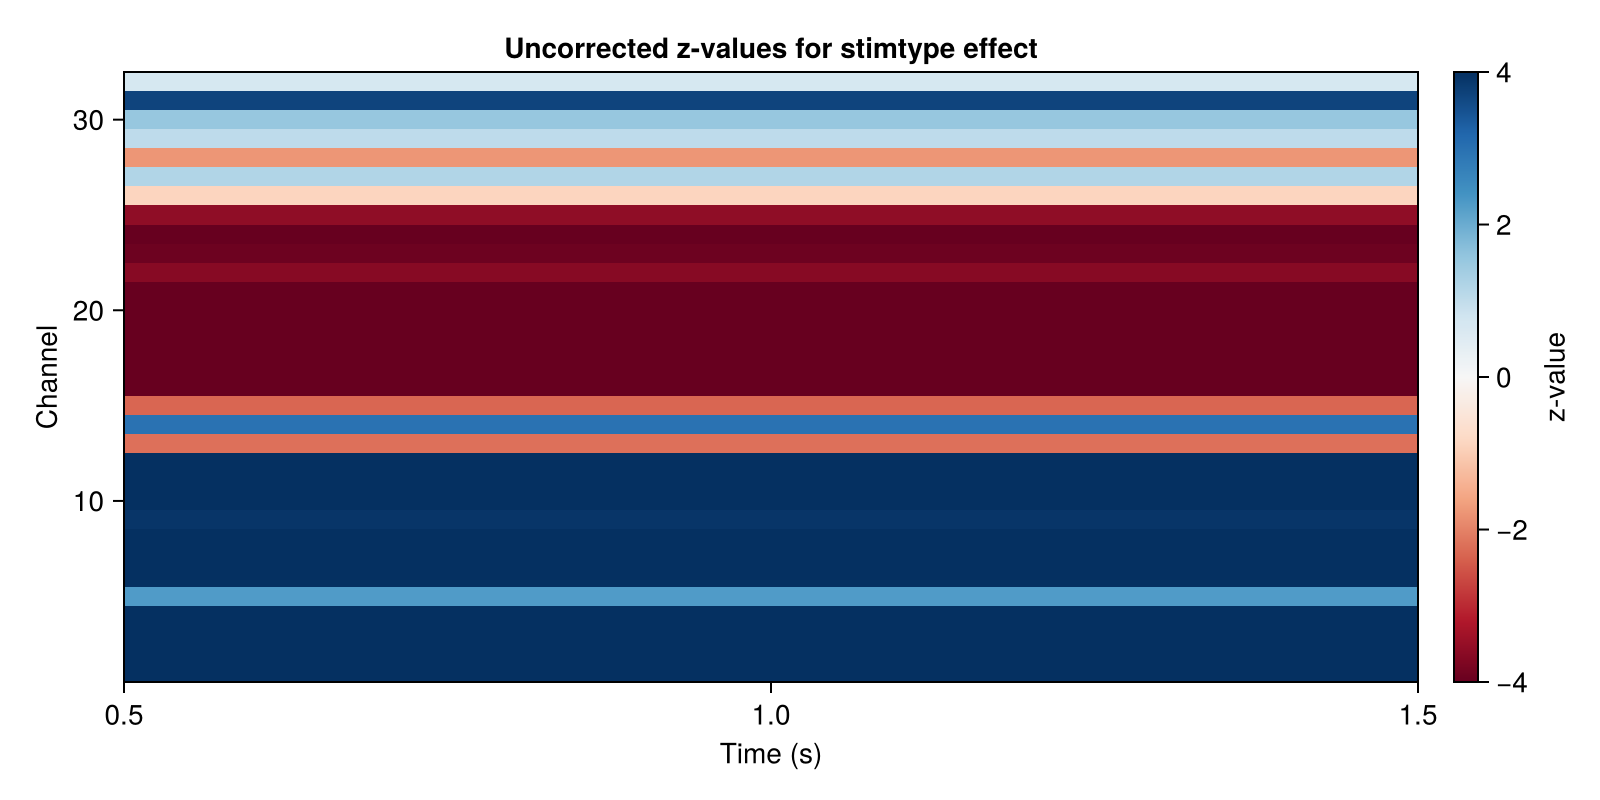

In [47]:
# Check uncorrected effects before running permutation test
# Extract coefficients for the stimtype effect
coefs = coeftable(m)

# Show available columns
println("Available columns: $(names(coefs))")

# Filter for stimtype coefficient
coef_stimtype = filter(r -> r.coefname == "stimtype: face", coefs)
println("Rows for stimtype: $(nrow(coef_stimtype))")

# Check how many unique channels and times we have
unique_channels = sort(unique(coef_stimtype.channel))
unique_times = sort(unique(coef_stimtype.time))
println("Unique channels: $(length(unique_channels))")
println("Unique times: $(length(unique_times))")

# Compute z-values from estimate/stderror, handling missing values
# Replace Nothing with NaN for computation
estimate_vec = [isnothing(x) ? NaN : Float64(x) for x in coef_stimtype.estimate]
stderror_vec = [isnothing(x) ? NaN : Float64(x) for x in coef_stimtype.stderror]
z_vec = estimate_vec ./ stderror_vec

coef_stimtype[!, :z] = z_vec

# Average across groups if there are multiple entries per channel×time
z_summary = combine(
    groupby(coef_stimtype, [:channel, :time]),
    :z => (x -> mean(filter(!isnan, x))) => :z
)
sort!(z_summary, [:channel, :time])

# Replace NaN with 0 for visualization
z_summary.z = replace(z_summary.z, NaN => 0.0)

# Reshape z-values to channels × times
n_ch_coef = length(unique_channels)
n_t_coef = length(unique_times)
z_vals = reshape(z_summary.z, n_t_coef, n_ch_coef)'  # (channels × times)

# Check for significant z-values (|z| > 2.0)
n_sig_uncorrected = sum(abs.(z_vals) .> 2.0)
max_z = maximum(abs.(z_vals))
peak_idx = argmax(abs.(z_vals))
peak_ch, peak_t = Tuple(CartesianIndices(z_vals)[peak_idx])

println("\n=== Uncorrected Effects (before permutation) ===")
println("Max |z|: $(round(max_z, digits=2))")
println("Peak location: channel $(electrode_labels[peak_ch]) at t = $(round(unique_times[peak_t], digits=3))s")
println("Samples with |z| > 2.0: $(n_sig_uncorrected) / $(length(z_vals))")
println("Samples with |z| > 1.96: $(sum(abs.(z_vals) .> 1.96)) (uncorrected p < 0.05)")

# Quick visualization of z-values
fig_z = Figure(size = (800, 400))
ax_z = Axis(fig_z[1, 1],
    title = "Uncorrected z-values for stimtype effect",
    xlabel = "Time (s)",
    ylabel = "Channel")
hm = heatmap!(ax_z, collect(unique_times), 1:n_ch_coef, z_vals', colormap = :RdBu, colorrange = (-4, 4))
Colorbar(fig_z[1, 2], hm, label = "z-value")
fig_z

In [57]:
electrode_labels

32-element Vector{String}:
 "Fp1"
 "AF3"
 "F7"
 "F3"
 "FC1"
 "FC5"
 "T7"
 "C3"
 "CP1"
 "CP5"
 ⋮
 "T8"
 "FC6"
 "FC2"
 "F4"
 "F8"
 "AF4"
 "Fp2"
 "Fz"
 "Cz"

Significant cluster IDs: [-1, 1]


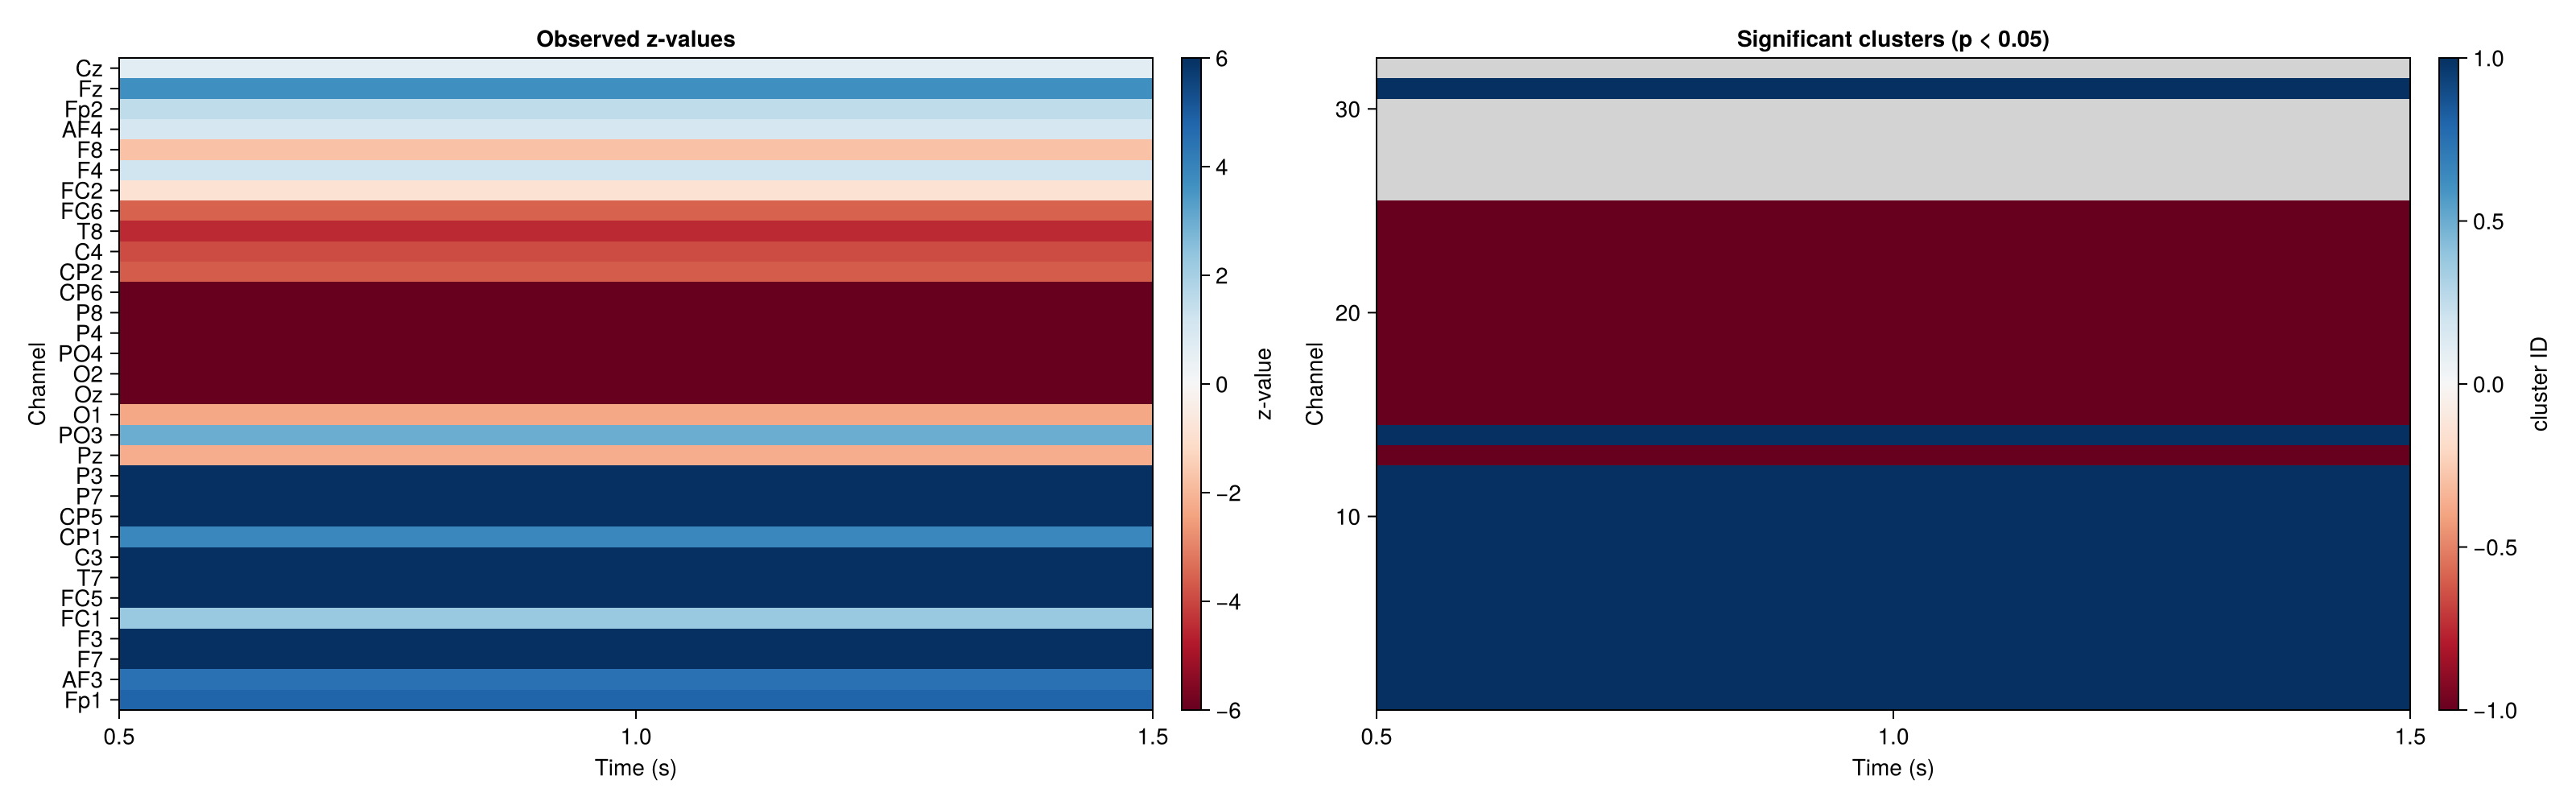

In [48]:
# 3. Run cluster-mass permutation test
observed = z_vals
pvals_clustermass, cluster_ids = spatiotemporal_cluster_pvalues(MersenneTwister(1), observed, permuted, adjacency, threshold)

# Only show significant clusters (p < 0.05); everything else → NaN (lightgray)
cluster_display = Float64.(cluster_ids)
cluster_display[(pvals_clustermass .>= 0.05) .| (cluster_ids .== 0)] .= NaN

sig_ids = sort(unique(cluster_ids[pvals_clustermass .< 0.05]))
println("Significant cluster IDs: $sig_ids")

n_clusters = maximum(abs.(cluster_ids))
crange = n_clusters == 0 ? (-1.0, 1.0) : (-Float64(n_clusters), Float64(n_clusters))

# 4. Visualize
fig = Figure(size = (1600, 500))

# Panel 1: Observed z-values with threshold contours
ax1 = Axis(fig[1, 1], title = "Observed z-values", xlabel = "Time (s)", ylabel = "Channel",
           yticks = (1:n_channels, electrode_labels))
hm1 = heatmap!(ax1, collect(times), 1:n_channels, z_vals', colormap = :RdBu, colorrange = (-6, 6))
Colorbar(fig[1, 2], hm1, label = "z-value")
contour!(ax1, collect(times), 1:n_channels, z_vals', levels = [threshold],  color = (:red,  0.7), linewidth = 1.5)
contour!(ax1, collect(times), 1:n_channels, z_vals', levels = [-threshold], color = (:blue, 0.7), linewidth = 1.5)

# Panel 2: Significant cluster labels only (warm = positive, cool = negative, gray = non-sig / no cluster)
ax2 = Axis(fig[1, 3], title = "Significant clusters (p < 0.05)",
           xlabel = "Time (s)", ylabel = "Channel")
hm2 = heatmap!(ax2, collect(times), 1:n_channels, cluster_display',
               colormap = :RdBu, colorrange = crange, nan_color = :lightgray)
Colorbar(fig[1, 4], hm2, label = "cluster ID")

fig

In [49]:
pvals_clustermass .< 0.05

32×1 BitMatrix:
 1
 1
 1
 1
 1
 1
 1
 1
 1
 1
 ⋮
 1
 1
 0
 0
 0
 0
 0
 1
 0

In [50]:
# create topoplot and butterfly plot for selected channels only
pos3d = hart.electrodes["pos"][channel_idx, :]  # 32x3 matrix for selected channels
pos2d = [Point2f(pos3d[i,1], pos3d[i,2]) for i in 1:size(pos3d,1)]  # convert to 2D points for topoplot
sig_mask = pvals_clustermass .< 0.05
cluster_data = copy(z_vals)
#cluster_data[.!sig_mask] .= 0.0  # Set non-significant to zero (or NaN)
# Ensure correct orientation: time x channels
df = DataFrame(
    :estimate => vec(cluster_data),  # no transpose, time is slow axis, channels is fast axis
    :channel => repeat(1:size(cluster_data, 1), outer = size(cluster_data, 2)),
    :time => repeat(1:size(cluster_data, 2), inner = size(cluster_data, 1))
)

Row,estimate,channel,time
,Float64,Int64,Int64
1,4.84839,1,1
2,4.5183,2,1
3,8.67073,3,1
4,6.67542,4,1
5,2.26831,5,1
6,8.31756,6,1
7,10.9134,7,1
8,8.32095,8,1
9,3.92034,9,1


Averaging across 1 time points
Any NaN in avg_topo: false


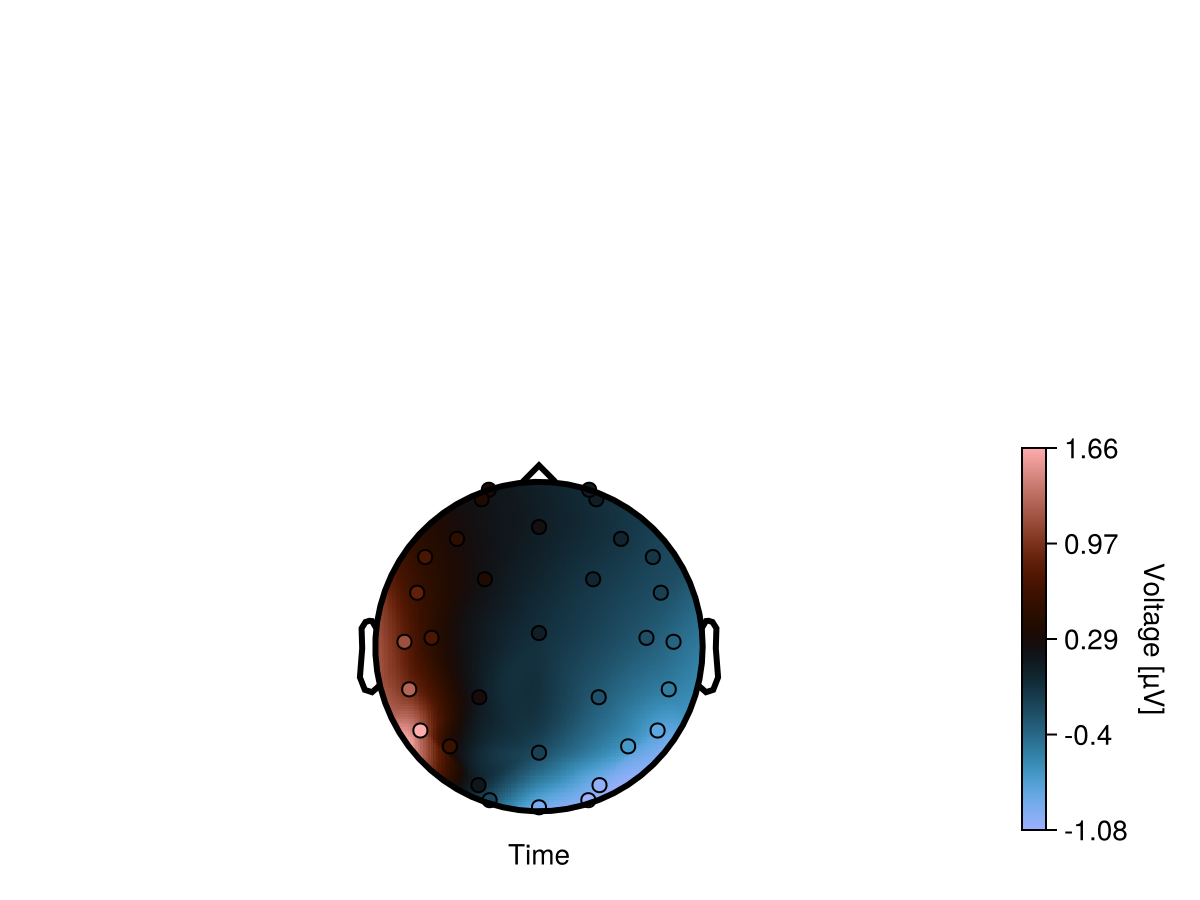

In [53]:
f = Figure()
# Average ERP across all trials for each channel and time
erp = mean(data_1t; dims=3)[:,:,1]  # (channels x times)
df_erp = DataFrame(
    :amplitude => vec(erp),
    :channel => repeat(1:size(erp, 1), outer = size(erp, 2)),
    :time => repeat(1:size(erp, 2), inner = size(erp, 1))
)
#plot_butterfly!(f[1, 1:2], df_erp; positions = pos2d, mapping=(; y=:amplitude))
# Find significant time points (p < 0.05)
# sig_mask is channels x times, so get time indices where any channel is significant
sig_time_bool = vec(any(sig_mask, dims=1))
unique_times = sort(unique(df_erp.time))
sig_times = unique_times[sig_time_bool]
if isempty(sig_times)
    @warn "No significant time points found; falling back to averaging across all times"
    sig_times = unique_times
end
println("Averaging across $(length(sig_times)) time points")
# Compute average topography robustly (avoid averaging over empty selection)
avg_topo = Float64[]
for ch in 1:n_channels
    sel = (df_erp.channel .== ch) .& in.(df_erp.time, Ref(sig_times))
    vals = df_erp.amplitude[sel]
    if isempty(vals)
        push!(avg_topo, NaN)
    else
        push!(avg_topo, mean(vals))
    end
end
println("Any NaN in avg_topo: ", any(isnan, avg_topo))
if any(isnan, avg_topo)
    @warn "avg_topo contains NaNs for channels: $(findall(isnan, avg_topo))"
end
# Highlight significant channels: a channel is significant if any time point is significant for it
sig_ch = [any(sig_mask[ch, :]) for ch in 1:n_channels]
# Set marker color: red for significant, gray for others
marker_colors = [is_sig ? :white : :gray for is_sig in sig_ch]
# Set marker size: larger for significant, smaller for others
marker_sizes = [is_sig ? 10 : 10 for is_sig in sig_ch]
plot_topoplot!(
    f[2, 1],
    DataFrame(:amplitude => avg_topo, :channel => 1:n_channels);
    positions = pos2d,
    mapping=(; y=:amplitude),
    visual = (; enlarge = 1, label_scatter = true, colormap = :berlin, contours = false),
    colorrange = (; colorrange = (-0.5, 0.5)),
    topo_attributes = (; label_scatter = (; color = marker_colors, markersize = marker_sizes)),
    )

f